In [1]:
# Import required libraries for GNSS time series analysis

import os
import pandas as pd                    # for handling tabular data
import numpy as np                     # for numerical operations
import matplotlib.pyplot as plt        # for plotting
from datetime import datetime          # for handling dates and times
from scipy.optimize import curve_fit   # for fitting 
from scipy.signal import detrend       # for linear detrending


# Use a clean plotting style
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
## call the GNSS files
# Path to the folder containing the processed CSV files
ts_dir = os.path.join('results', 'processed_ts')

# Initialize dictionary to store DataFrames by station code
ts_dict = {}

# Loop through all CSV files in the folder
for file in os.listdir(ts_dir):
    if file.endswith('_processed.csv'):
        station = file.split('_')[0]  # Extract station name from filename
        df = pd.read_csv(os.path.join(ts_dir, file))
        df['Date'] = pd.to_datetime(df['Date'])  # Ensure Date column is datetime

        # Calculate decimal year
        df['stat_decimal_year'] = df['Date'].dt.year + \
                            (df['Date'].dt.dayofyear - 1 +
                            df['Date'].dt.hour / 24 +
                            df['Date'].dt.minute / 1440 +
                            df['Date'].dt.second / 86400) / 365.25
        
        ts_dict[station] = df

print("Stations loaded:", list(ts_dict.keys()))


Stations loaded: ['EART', 'CDTO', 'CABA', 'OVSI', 'HATI', 'ELVI', 'LBRA', 'QSEC', 'PAND', 'MUEL', 'CHLS', 'COBB', 'OCHA', 'VERA', 'LAFE', 'RIFO', 'BIJA', 'CRU2', 'HORI', 'PNE2', 'SRBA', 'PN01', 'QPSB', 'COVE', 'CHOM', 'PUJE', 'LIMN', 'LMNL', 'ABEJ', 'RIDC', 'CAPO', 'BRBR', 'IND1', 'PEZE', 'OROT', 'SAJU', 'POTG', 'JACO', 'PUNT', 'GRZA', 'VRAI', 'LOL2', 'CTCR', 'AROL', 'CDME', 'PLAN', 'BON2', 'VISP', 'PUMO']


In [3]:
### get the reference position for the station from original '.ovs.final_igb14.pos' position file
datadir = 'POS-FILES_1days-sol'
file = os.path.join(datadir, station + '.ovs.final_igb14.pos')

stations = []
lats = []
lons = []
heights = []

for station in ts_dict.keys(): #use the stations in the ts_dict
    file = os.path.join(datadir, station + '.ovs.final_igb14.pos')
    with open(file, 'r') as csv_file:
        for line in open(file, 'r'):
            if line.startswith("NEU Reference position"):
                words = line.split()
                lat, lon, height = float(words[4]), float(words[5]) - 360, float(words[6])
                lats.append(lat)
                lons.append(lon)
                heights.append(height)
                stations.append(station)
                #print(f"Station {station} → lat: {lat}, lon: {lon}, height: {height}")
                break  # Exit after finding the reference position

# Create a DataFrame for station reference positions
station_coords = pd.DataFrame({
    'Station': stations,
    'Latitude': lats,
    'Longitude': lons,
    'Height': heights
})

print(station_coords)

   Station   Latitude  Longitude      Height
0     EART  10.212643 -83.594314    45.34842
1     CDTO   8.573239 -82.872670   100.04896
2     CABA  10.237873 -85.343535    26.91355
3     OVSI  10.001844 -84.111310  1180.67832
4     HATI  10.292197 -85.710063    58.62959
5     ELVI  10.394696 -85.445807    81.83019
6     LBRA  10.630958 -85.437983   160.25435
7     QSEC   9.840380 -85.357274    17.64548
8     PAND   9.735037 -82.976946    47.97158
9     MUEL  10.474832 -84.463665    81.30609
10    CHLS  11.031315 -84.710059    51.38720
11    COBB   9.688133 -85.106939   172.46801
12    OCHA   9.097512 -83.645619   109.71316
13    VERA  10.853618 -84.869043    64.31335
14    LAFE   9.807062 -84.960284    65.26984
15    RIFO  10.317285 -83.922645   116.25661
16    BIJA   9.749975 -84.576870   555.63084
17    CRU2  11.054023 -85.633446   270.83837
18    HORI  10.713677 -85.595396   173.40930
19    PNE2  10.195164 -85.828710    19.64030
20    SRBA   9.232141 -83.360050   940.00337
21    PN01

In [4]:
## Call the centroid catalog earthquake catalog
## Define the path to centroid catalog 
eq_file_path = os.path.join('processing', 'bigger_6.txt')

# Column names
columns = [
    "year", "month", "day", "hour", "minute", "sec",
    "hyp_lat", "hyp_lon", "hyp_depth", "mw",
    "cmt_mw", "cmt_lat", "cmt_lon", "cmt_depth", "St1", "D1", "Slip1", "St12", "D2", "Slip2",
]
# Read the file
eq_df = pd.read_csv(eq_file_path, delim_whitespace=True, header=None, names=columns, skiprows=1)
print(f"Loaded {len(eq_df)} earthquakes from {eq_file_path}.")

# Convert to datetime
eq_df['event_time'] = pd.to_datetime(eq_df[['year', 'month', 'day', 'hour', 'minute']].assign(
    second=eq_df['sec']
))

# Convert to decimal year
eq_df['decimal_year'] = eq_df['event_time'].dt.year + \
                        (eq_df['event_time'].dt.dayofyear - 1 +
                         eq_df['event_time'].dt.hour / 24 +
                         eq_df['event_time'].dt.minute / 1440 +
                         eq_df['event_time'].dt.second / 86400) / \
                        (365.25)


# Show a preview
eq_df['decimal_year'].iloc[0]

print(eq_df.head())


Loaded 25 earthquakes from processing/bigger_6.txt.
   year  month  day  hour  minute   sec  hyp_lat  hyp_lon  hyp_depth   mw  \
0  2002      6   16     2      46  14.0     8.78   -83.99       35.0  5.4   
1  2002      7   31     0      16  44.6     7.93   -82.79       10.0  6.0   
2  2003     12   25     7      11  11.6     8.42   -82.82       33.0  6.0   
3  2004      4   29     0      57  21.1    10.81   -86.00       10.0  5.6   
4  2004     11   20     8       7  22.1     9.60   -84.17       16.0  6.2   

   ...  cmt_lon  cmt_depth  St1  D1  Slip1  St12  D2  Slip2  \
0  ...   -84.14      15.00  303  13    101   112  77     87   
1  ...   -82.92      17.00  260  73     -1   350  89   -163   
2  ...   -82.81      30.12   12  85    176   103  86      5   
3  ...   -86.38      19.00  309  15     97   121  75     88   
4  ...   -84.32      22.00  204  49    -16   305  78   -138   

               event_time  decimal_year  
0 2002-06-16 02:46:14.000   2002.454799  
1 2002-07-31 00:16:44.

/var/folders/fm/zxb00jfj0zdcxft7sfv1gps00000gn/T/ipykernel_5856/3021097467.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  eq_df = pd.read_csv(eq_file_path, delim_whitespace=True, header=None, names=columns, skiprows=1)


In [5]:
## this block is to clasify the earthquakes according to Wells and Coppersmith (1994)
## and get the average slip

def classify_earthquake(rake):
    """
    Classify the earthquake based on rake
    """
    if rake == 90:
        return 'R'  # Pure reverse
    elif rake == -90:
        return 'N'  # Pure normal
    elif rake == 0 or rake == 180 or rake == -180:
        return 'SS'  # Pure strike-slip
    elif -20 <= rake <= 20:
        return 'SS'  # Left-lateral strike-slip (still strike-slip)
    elif 70 <= rake <= 110:
        return 'R'  # Reverse
    elif -110 <= rake <= -70:
        return 'N'  # Normal
    elif 20 < rake < 70 or 110 < rake < 160 or -160 < rake < -110 or -70 < rake < -20:
        return 'A'  # Oblique types
    else:
        return 'A'
    
eq_df['fault_type'] = eq_df['Slip1'].apply(classify_earthquake) # Classify earthquakes based on Slip1 rake

# Calculate average slip for each fault type
wells_path = os.path.join('processing', 'displacements_wells_A.txt')
wells_df = pd.read_csv(wells_path, sep='\s+', comment='#')
print(wells_df['slip_type'].unique())  # ['SS', 'R', 'N', 'A'] # Check unique fault types

# Filter equation parameters 
averge_equation = wells_df[wells_df['Equation'] == 4].copy()

# Merge to get average slip
eq_df = eq_df.merge(averge_equation[['slip_type', 'a', 'b']], 
                    left_on='fault_type', right_on='slip_type', how='left')
eq_df.drop(columns=['slip_type'], inplace=True)  # Drop redundant column
#print(eq_df.head())  # Check the first few rows to ensure 'a' and 'b' are added correctly

eq_df['average_disp_m'] = 10 ** (eq_df['a'] + eq_df['b'] * eq_df['cmt_mw'])

print(eq_df.head()) 
eq_df.to_csv('results/eq_catalog_with_slip.csv', index=False)


['SS' 'R' 'N' 'A']
   year  month  day  hour  minute   sec  hyp_lat  hyp_lon  hyp_depth   mw  \
0  2002      6   16     2      46  14.0     8.78   -83.99       35.0  5.4   
1  2002      7   31     0      16  44.6     7.93   -82.79       10.0  6.0   
2  2003     12   25     7      11  11.6     8.42   -82.82       33.0  6.0   
3  2004      4   29     0      57  21.1    10.81   -86.00       10.0  5.6   
4  2004     11   20     8       7  22.1     9.60   -84.17       16.0  6.2   

   ...  Slip1  St12  D2  Slip2              event_time  decimal_year  \
0  ...    101   112  77     87 2002-06-16 02:46:14.000   2002.454799   
1  ...     -1   350  89   -163 2002-07-31 00:16:44.600   2002.577718   
2  ...    176   103  86      5 2003-12-25 07:11:11.600   2003.980970   
3  ...     97   121  75     88 2004-04-29 00:57:21.100   2004.325913   
4  ...    -16   305  78   -138 2004-11-20 08:07:22.100   2004.887990   

   fault_type     a     b  average_disp_m  
0           R -0.74  0.08        0.570164

<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/var/folders/fm/zxb00jfj0zdcxft7sfv1gps00000gn/T/ipykernel_5856/3054974968.py:29: SyntaxWarning: invalid escape sequence '\s'
  wells_df = pd.read_csv(wells_path, sep='\s+', comment='#')


In [6]:
def compute_3d_distance(station_lat, station_lon, station_height, earthquake_lat, earthquake_lon, eathquake_depth):
    """
    Compute 3D distance between station (lat, long, height) and earthquake centroid (lat2, lon2, cw_depth).
    
    Inputs:
    - lat, long: station latitude and longitude in degrees
    - height: station elevation in meters
    - lat2, lon2: earthquake latitude and longitude in degrees
    - cw_depth: earthquake centroid depth in kilometers

    Returns:
    - 3D distance in kilometers
    """
    R = 6371.0  # Earth radius in km

    # Convert coordinates to radians
    phi1 = np.radians(station_lat)
    phi2 = np.radians(earthquake_lat)
    dphi = np.radians(earthquake_lat - station_lat)
    dlambda = np.radians(earthquake_lon - station_lon)

    # Haversine formula for surface distance
    a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    surface_dist = R * c  # in km

    # Convert station height from meters to kilometers
    elev_km = station_height / 1000.0

    # Total vertical separation between station and earthquake centroid
    vertical_diff = eathquake_depth + elev_km  # both in km

    # Compute total 3D distance
    return np.sqrt(surface_dist**2 + vertical_diff**2)


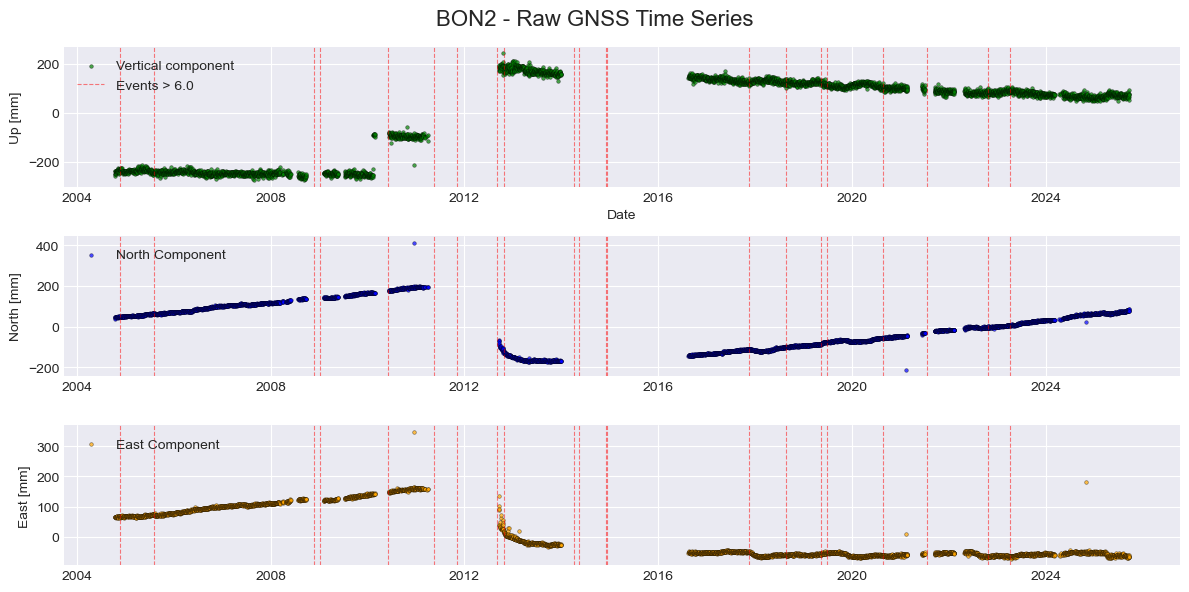

In [7]:
# Plot raw GNSS time series for a selected station, with earthquake events marked as vertical lines

station = 'BON2'  # Change this to any station
#station = list(ts_dict.keys())[0]  # Automatically get the first station
df_sample_st = ts_dict[station].copy() 

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.scatter(df_sample_st['Date'], df_sample_st['Upos'] * 1000, label='Vertical component', color='green', linewidth=0.3, s=7, alpha=0.7, edgecolors='black') 
plt.ylabel('Up [mm]')
plt.xlabel('Date')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.scatter(df_sample_st['Date'], df_sample_st['Npos'] * 1000, label='North Component', color='blue', linewidth=0.3,  s=7, alpha=0.7, edgecolors='black')
plt.ylabel('North [mm]')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.scatter(df_sample_st['Date'], df_sample_st['Epos'] * 1000, label='East Component', color='orange', linewidth=0.3,  s=7, alpha=0.7, edgecolors='black')
plt.ylabel('East [mm]')
plt.grid(True)


# filter earthquake data to only include events after the start date of the GNSS time series
start_date = df_sample_st['Date'].min()  # Get the minimum date from the GNSS data
eq_df_filtered = eq_df[eq_df['event_time'] >= start_date]

for ax_idx, ax in enumerate(plt.gcf().axes):
    for i, eq_time in enumerate(eq_df_filtered['event_time']):
        ax.axvline(
            eq_time,
            color='red',
            linestyle='--',
            alpha=0.5,
            linewidth=0.8,
            label='Events > 6.0' if (i == 0 and ax_idx == 0) else None
        )

for ax in plt.gcf().axes:
    ax.legend(loc='upper left')

plt.suptitle(f'{station} - Raw GNSS Time Series', fontsize=16)
plt.tight_layout()
plt.show()


In [8]:
# ### this block is for fitting the model around all earthquake events.

def multi_event_model_weighted(t, a_list, uC_list, m, c, eq_times, weights):
    """
    Time series model with multiple earthquakes:
    - Linear trend: m * t + c
    - For each earthquake:
        - Coseismic step: uC * Heaviside(t - t_eq)
        - Logarithmic postseismic decay: a * log(t - t_eq)

    Parameters:
    - t: array of decimal years
    - a_list: list of postseismic log amplitudes
    - uC_list: list of coseismic step amplitudes
    - m, c: linear trend parameters
    - eq_times: list of decimal year times for each earthquake
    - weights: list of weights for each earthquakse bsed on distanced and average slip

    Returns:
    - y: modelled time series
    """
    # Ensure t is a numpy array for vectorized operations
    t = np.asarray(t)
    
    # Initialize the model with the linear part
    y = m * t + c
    
    # Loop through each earthquake event
    for i, t_eq in enumerate(eq_times):
        # Coseismic step
        y += weights[i] * uC_list[i] * np.heaviside(t - t_eq, 1)
        # Logarithmic postseismic decay
        mask = t > t_eq
        y[mask] += weights[i] * a_list[i] * np.log(t[mask] - t_eq + 1e-6)
    return y


In [9]:
# ## this block is for fitting the model around all earthquake events using all stations one by one 

# Get components
components = ['Npos', 'Epos', 'Upos']

# file where the plots will be saved
plot_dir = os.path.join('results', 'fitted_coseismic_plots')
os.makedirs(plot_dir, exist_ok=True)

# Store results for all stations
all_results = {}

for station, df in ts_dict.items():
    print(f"\n=== Processing station {station} ===")
    df = df.copy()

    # Filter earthquake data to only include events after the start date of the GNSS time series

    t = df['stat_decimal_year'].to_numpy()
    if t.size == 0 or np.all(np.isnan(t)):
        print(f"{station}: No valid time data available. Skipping.")
        all_results[station] = df
        continue

    tmin = np.nanmin(t)
    tmax = np.nanmax(t)

    # coordinates of the station (for weights) from station_coords DataFrame
    row = station_coords[station_coords['Station'] == station]
    if row.empty:
        print(f"Coordinates for station {station} not found. Skipping.")
        all_results[station] = df
        continue

    # station coordinates saved
    st_lat = row['Latitude'].values[0] #other options: row.iloc[0]['Latitude']
    st_lon = row['Longitude'].values[0]
    st_h   = row['Height'].values[0]

    ## Filter earthquakes after the start of the series
    if 'decimal_year' not in eq_df_filtered.columns:
        raise KeyError("Missing 'decimal_year' in eq_df_filtered.")
    
    #filter earthquakes between tmin and tmax per station
    eq_sel = eq_df[(eq_df['decimal_year'] >= tmin) & (eq_df['decimal_year'] <= tmax)].copy()   
    
    #maintain order in time
    eq_sel = eq_sel.sort_values(by='decimal_year', kind='mergesort')

    #build eq_times and N for this station
    eq_times = eq_sel['decimal_year'].to_numpy()
    N = len(eq_times)

    if N == 0:
        print(f"{station}: there is no earthquake event in the time range. Skipping.")
        all_results[station] = df
        continue

    # eq_times = eq_df_filtered['decimal_year'].to_numpy()
    # eq_times = eq_times[eq_times >= np.nanmin(t)]
    # eq_times = np.sort(eq_times)
    # if N == 0:
    #     print(f"{station}: there is no eart.")
    #     all_results[station] = df
    #     continue


    xi = compute_3d_distance(
    st_lat, st_lon, st_h,
    eq_sel['cmt_lat'].to_numpy(),
    eq_sel['cmt_lon'].to_numpy(),
    eq_sel['cmt_depth'].to_numpy()
)

    xi = np.asarray(xi, dtype=float)
    xi[xi == 0] = 1e-6  # evitar división por cero

    wi = (eq_sel['average_disp_m'].to_numpy() ** 2) / (xi ** 2)

    # Figure per station
    fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True, sharey=True)

    for i, comp in enumerate(components):
        if comp not in df.columns:
            print(f"{station}: component {comp} is not in the dataframe. Skipping.")
            continue

        print(f"{station}: fitting component {comp}")
        y = df[comp].to_numpy()

        # Initial values
        a0 = [0.005] * N
        uC0 = [0.01] * N
        m0 = 0.0
        c0 = y[0] if len(y) > 0 else 0.0
        p0 = a0 + uC0 + [m0, c0]

        # Fit the model with error handling
        try:
            params, _ = curve_fit(
                lambda tt, *pp: multi_event_model_weighted(
                    tt, pp[:N], pp[N:2*N], pp[2*N], pp[2*N+1], eq_times, wi
                ),
                t, y, p0=p0, maxfev=20000
            )
        except Exception as e:
            print(f"{station} / {comp}: Fitting failed -> {e}")
            continue

        # Parameters and fitted series
        a_fit  = params[:N]
        uC_fit = params[N:2*N]
        m_fit  = params[2*N]
        c_fit  = params[2*N+1]

        fitted   = multi_event_model_weighted(t, a_fit, uC_fit, m_fit, c_fit, eq_times, wi)
        residual = y - fitted

        # Store results in DataFrame
        df[f'{comp}_fitted']   = fitted
        df[f'{comp}_residual'] = residual

        # Plot
        ax[i].scatter(df['Date'], y, color='lightblue', linewidth=0.3,  s=10, alpha=0.7, edgecolors='black', label='Observed data')
        ax[i].plot(df['Date'], fitted, linestyle='--', color='red', linewidth=1.5, label='Fitted model')

        # earthquake lines
        for k, eq_time in enumerate(eq_times):
            ax[i].axvline(
                pd.to_datetime(f"{int(eq_time)}-01-01") + pd.to_timedelta((eq_time % 1) * 365.25, unit='D'),
                linestyle='--', linewidth=0.8
            )
        ax[i].set_ylabel(f'{comp} (m)')
        ax[i].grid(True)
        ax[i].set_title(f'{station} - {comp}')

        # Log fit parameters 
        print(f"{station} / {comp}: m={m_fit:.6e}, c={c_fit:.6e} | "
            f"a[:3]={a_fit[:3] if N>=3 else a_fit} | uC[:3]={uC_fit[:3] if N>=3 else uC_fit}")

    ax[-1].set_xlabel('Time')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save figure per station 
    out_png = os.path.join(plot_dir, f"{station}_fit.png")
    try:
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.close(fig) # Close the figure to free memory
        print(f"Figure saved: {out_png}")

    except Exception as e:
        print(f"Can´t save figure {station}: {e}")
    # plt.show()

    # Update results per station
    all_results[station] = df

# save the updated time series with fitted and residuals if needed
ts_dict.update(all_results)

print("\nAdjust completed for all stations.")



=== Processing station EART ===
EART: fitting component Npos
EART / Npos: m=1.282183e-02, c=-2.590626e+01 | a[:3]=[  -31.38760448   -61.25008033 -1188.403064  ] | uC[:3]=[ -320.6750273   -242.57072095 -4834.38954727]
EART: fitting component Epos
EART / Epos: m=2.233698e-04, c=-4.506325e-01 | a[:3]=[  11.43852708   53.75193274 1624.91221689] | uC[:3]=[ -259.48686817    70.79299661 12808.36634155]
EART: fitting component Upos
EART / Upos: m=2.733596e-04, c=-5.468621e-01 | a[:3]=[ -40.16528203  274.94337733 1758.56201828] | uC[:3]=[   17.54464446    52.64397722 12196.25739853]
Figure saved: results/fitted_coseismic_plots/EART_fit.png

=== Processing station CDTO ===
CDTO: fitting component Npos
CDTO / Npos: m=2.439748e-02, c=-4.916579e+01 | a[:3]=[   6143.06095409 -135750.59201576     167.18248564] | uC[:3]=[ 1.54042225e+06 -3.30433574e+07  6.93068396e+02]
CDTO: fitting component Epos
CDTO / Epos: m=3.129114e-03, c=-6.295531e+00 | a[:3]=[ 2.82377571e+04 -5.33512811e+05  4.63376288e+01] |

/var/folders/fm/zxb00jfj0zdcxft7sfv1gps00000gn/T/ipykernel_5856/719237678.py:100: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


Figure saved: results/fitted_coseismic_plots/IND1_fit.png

=== Processing station PEZE ===
PEZE: fitting component Npos
PEZE / Npos: m=2.678054e-02, c=-5.401263e+01 | a[:3]=[-2.10387548e+05  1.49757668e+05 -5.22503521e+01] | uC[:3]=[ 2.79423655e+07 -5.53752828e+07 -9.07906113e+02]
PEZE: fitting component Epos
PEZE / Epos: m=1.614743e-02, c=-3.244956e+01 | a[:3]=[-4.42035344e+05  2.97342532e+05 -1.10179246e+02] | uC[:3]=[ 1.11324448e+08 -2.20802492e+08 -2.18882089e+03]
PEZE: fitting component Upos
PEZE / Upos: m=-1.926196e-02, c=3.874138e+01 | a[:3]=[ 5.85246105e+05 -4.15916870e+05 -3.54057829e+02] | uC[:3]=[-6.54339692e+07  1.29658028e+08 -4.51079009e+03]
Figure saved: results/fitted_coseismic_plots/PEZE_fit.png

=== Processing station OROT ===
OROT: fitting component Npos
OROT / Npos: m=2.149011e-02, c=-4.341546e+01 | a[:3]=[ -516.70820178   -80.61181209 -2315.75270838] | uC[:3]=[-2714.06533517 49381.69238258 -9256.5377581 ]
OROT: fitting component Epos
OROT / Epos: m=-2.680370e-03, c

In [ ]:
# ### this block is for plotting the residuals only for all stations one by one

# create output directories
plot_residuals_dir = os.path.join('results', 'fitting_residuals_plots')
csv_out_dir        = os.path.join('results', 'fit_csv')
os.makedirs(plot_residuals_dir, exist_ok=True)
os.makedirs(csv_out_dir, exist_ok=True)

skipped_stations = []

for station, df in all_results.items():
    print(f"\n=== Processing station {station} ===")
    df = df.copy()

    # Basic checks
    if 'Date' not in df.columns or 'stat_decimal_year' not in df.columns:
        print(f"{station}: missing Date/stat_decimal_year; skipping station.")
        skipped_stations.append(station)
        continue

    # Time vector and span for this station
    t = df['stat_decimal_year'].to_numpy()
    if t.size == 0 or np.all(np.isnan(t)):
        print(f"{station}: no valid time data; skipping station.")
        skipped_stations.append(station)
        continue
    tmin = np.nanmin(t)
    tmax = np.nanmax(t)

    # ---------- PHASE 1: compute residuals (if not already present) ----------
    ## here is where we compute the residuals 
    for comp in components:
        if comp not in df.columns:
            print(f"{station}: component {comp} not found; skipping this component in residuals computation.")
            continue

        res_col = f"{comp}_residual"
        if res_col in df.columns:
            continue  # already computed

        fit_col = f"{comp}_fitted"
        if fit_col in df.columns:
            y      = np.asarray(df[comp].to_numpy(), dtype=float)
            fitted = np.asarray(df[fit_col].to_numpy(), dtype=float)
            if y.shape != fitted.shape:
                print(f"{station}: {comp} y/fitted length mismatch ({y.size} vs {fitted.size}); skipping this component.")
                continue
            df[res_col] = y - fitted ## here is where we compute the residuals!!
        ## if fitted column does not exist then we cannot compute residuals
        else:
            print(f"{station}: {comp} has no fitted column; cannot compute residuals for this component.")

    # If no residual columns exist for any component, skip plotting/saving
    if not any((f"{c}_residual" in df.columns) for c in components):
        print(f"{station}: no residual columns available; skipping station.")
        skipped_stations.append(station)
        continue

    # ---------- EQ LINES (your snippet adapted to eq_df) ----------
    # Filter earthquakes after the start of the series and within [tmin, tmax]
    if 'eq_df' in globals() and isinstance(eq_df, pd.DataFrame):
        if 'decimal_year' not in eq_df.columns:
            raise KeyError("Missing 'decimal_year' in eq_df.")
        # filter earthquakes between tmin and tmax per station
        eq_sel = eq_df[(eq_df['decimal_year'] >= tmin) & (eq_df['decimal_year'] <= tmax)].copy()
        # maintain order in time
        eq_sel = eq_sel.sort_values(by='decimal_year', kind='mergesort')
        # build eq_times and N for this station
        eq_times = eq_sel['decimal_year'].to_numpy()
        N = len(eq_times)
    else:
        # If eq_df is not available, just skip EQ lines, wont plot them
        eq_times = np.array([])
        N = 0

    # ---------- PHASE 2: plot residuals and save outputs ----------
    fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True, sharey=True)
    plotted_any = False

    for i, comp in enumerate(components):
        res_col = f"{comp}_residual"
        if res_col not in df.columns:
            print(f"{station}: residuals for {comp} not found; skipping this component.")
            continue

        residual = np.asarray(df[res_col].to_numpy(), dtype=float)

        # Length check against Date
        if residual.shape[0] != df['Date'].shape[0]:
            print(f"{station}: {comp} length mismatch (Date={df['Date'].shape[0]} vs residual={residual.shape[0]}); skipping this component.")
            continue

        # Plot residuals
        ax[i].plot(df['Date'], residual, color='gray', linewidth=0.9, label='residual')
        ax[i].axhline(0, color='black', linestyle='--', linewidth=0.5)

        # Optional earthquake vertical lines (from eq_times above)
        if eq_times.size > 0:
            added_label = False
            for eq_time in eq_times:
                ts = pd.to_datetime(f"{int(eq_time)}-01-01") + pd.to_timedelta((eq_time % 1) * 365.25, unit='D')
                ax[i].axvline(
                    ts, color='red', linestyle='--', linewidth=0.5,
                    label='Earthquake time' if not added_label else None
                )
                added_label = True

        ax[i].set_ylabel(f'{comp} (m)')
        ax[i].legend(loc='upper left')
        ax[i].grid(True)
        ax[i].set_title(f'{station} - {comp} Residuals')
        plotted_any = True

    ax[-1].set_xlabel('Time')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    

    if plotted_any:
        # Save PNG
        out_png = os.path.join(plot_residuals_dir, f"{station}_residuals.png")
        try:
            plt.savefig(out_png, dpi=150, bbox_inches='tight')
            print(f"Saved figure: {out_png}")
        except Exception as e:
            print(f"Cannot save figure for {station}: {e}")
        plt.close(fig)

        # Save CSV with updated residuals
        out_csv = os.path.join(csv_out_dir, f"{station}_detrended_full.csv")
        df.to_csv(out_csv, index=False)
        print(f"Saved data: {out_csv}")

        # Update in-memory dict (optional, if reused later)
        all_results[station] = df
    else:
        plt.close(fig)
        print(f"{station}: no components plotted; skipping save.")
        skipped_stations.append(station)

print("\nDone. Figures in results/fitting_residuals, CSVs in results/fit_csv.")
if skipped_stations:
    print("Stations skipped:", sorted(set(skipped_stations)))



=== Processing station EART ===
Saved figure: results/fitting_residuals_plots/EART_residuals.png
Saved data: results/fit_csv/EART_detrended_full.csv

=== Processing station CDTO ===
Saved figure: results/fitting_residuals_plots/CDTO_residuals.png
Saved data: results/fit_csv/CDTO_detrended_full.csv

=== Processing station CABA ===
Saved figure: results/fitting_residuals_plots/CABA_residuals.png
Saved data: results/fit_csv/CABA_detrended_full.csv

=== Processing station OVSI ===
Saved figure: results/fitting_residuals_plots/OVSI_residuals.png
Saved data: results/fit_csv/OVSI_detrended_full.csv

=== Processing station HATI ===
Saved figure: results/fitting_residuals_plots/HATI_residuals.png
Saved data: results/fit_csv/HATI_detrended_full.csv

=== Processing station ELVI ===
Saved figure: results/fitting_residuals_plots/ELVI_residuals.png
Saved data: results/fit_csv/ELVI_detrended_full.csv

=== Processing station LBRA ===
Saved figure: results/fitting_residuals_plots/LBRA_residuals.png
Sa